<a href="https://colab.research.google.com/github/etooooooooo/Gruppo-1--Data-Science/blob/Miriam-branch/analisi_credit_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsione dell'insolvenza creditizia — Credit Card Default

**Corso:** Introduzione al Pensiero Computazionale e alla Data Science (a.a. 2025/26)

**Gruppo N. [numero]:** Membro 1 [Cognome Nome, matricola], Membro 2 [Cognome Nome, matricola]

**Obiettivo:** prevedere se un cliente sarà insolvente (*default*) sul pagamento della carta di credito nel mese successivo, a partire da caratteristiche demografiche, limite di credito e storico dei pagamenti.

Il notebook segue le fasi indicate nelle specifiche di progetto:
1. descrizione e comprensione del dataset
2. analisi esplorativa e visualizzazione
3. modellazione (3 modelli: regressione logistica, k-NN, Random Forest)
4. valutazione e interpretazione dei risultati

> **Nota sull'uso di assistenti LLM:** per la stesura di questo notebook è stato utilizzato un assistente LLM (Claude) come supporto alla programmazione e all'organizzazione del lavoro. Tutto il codice è stato rivisto, compreso e commentato dai membri del gruppo.

## 1. Setup e caricamento dei dati

Importiamo le librerie viste a lezione: `pandas` per i dati tabellari, `seaborn` e `matplotlib` per i grafici, `scikit-learn` per i modelli di machine learning.

Il file CSV ha una particolarità: contiene **due righe di intestazione** (la prima con i codici X1–X23, la seconda con i nomi reali delle variabili). Usiamo `header=1` per leggere la seconda riga come intestazione.

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score,
                             recall_score, f1_score)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("sample_data/Credit_Card_Default.csv", header=1)
# rinominiamo il target con un nome più comodo
df = df.rename(columns={"default payment next month": "DEFAULT"})
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Ogni riga rappresenta un cliente. Le variabili principali (dal file di descrizione):

- `LIMIT_BAL`: credito concesso (dollari taiwanesi, NT$)
- `SEX` (1 = uomo, 2 = donna), `EDUCATION` (1 = post-laurea, 2 = università, 3 = superiori, 4 = altro), `MARRIAGE` (1 = sposato, 2 = single, 3 = altro), `AGE` (anni)
- `PAY_0` … `PAY_6`: stato dei pagamenti da settembre (PAY_0) ad aprile (PAY_6); -1 = pagato puntualmente, 1 = ritardo di un mese, 2 = ritardo di due mesi, ecc.
- `BILL_AMT1` … `BILL_AMT6`: importo dell'estratto conto da settembre ad aprile
- `PAY_AMT1` … `PAY_AMT6`: importo pagato da settembre ad aprile
- `DEFAULT`: variabile target (1 = insolvente il mese successivo, 0 = solvente)

## Fase 2 — Descrizione e comprensione del dataset

In questa fase rispondiamo a una serie di domande sulla struttura, qualità e limiti dei dati.

### Domanda 2.1 — Quante osservazioni e quante variabili contiene il dataset? Di che tipo sono?

In [23]:
print("Dimensioni (righe, colonne):", df.shape)
df.info()

Dimensioni (righe, colonne): (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3 

**Risposta:** il dataset contiene **30.000 clienti** e **25 colonne** (l'identificativo `ID`, 23 variabili esplicative e il target `DEFAULT`). Tutte le variabili sono di tipo intero: anche quelle concettualmente categoriche (`SEX`, `EDUCATION`, `MARRIAGE`) sono codificate con numeri.

### Domanda 2.2 — Ci sono valori mancanti o righe duplicate?

In [24]:
print("Valori mancanti totali:", df.isnull().sum().sum())
print("ID duplicati:", df["ID"].duplicated().sum())
print("Righe interamente duplicate (escluso ID):", df.drop(columns="ID").duplicated().sum())

Valori mancanti totali: 0
ID duplicati: 0
Righe interamente duplicate (escluso ID): 35


**Risposta:** non ci sono valori mancanti né ID duplicati. Esistono alcune righe identiche su tutte le variabili (clienti diversi con stessi valori): essendo poche su 30.000 e plausibili (es. clienti inattivi con tutti zero), le manteniamo.

### Domanda 2.3 — Come è distribuita la variabile target? Le classi sono bilanciate?

In [25]:
print(df["DEFAULT"].value_counts())
print()
print(df["DEFAULT"].value_counts(normalize=True).round(3))

DEFAULT
0    23364
1     6636
Name: count, dtype: int64

DEFAULT
0    0.779
1    0.221
Name: proportion, dtype: float64


**Risposta:** il **22,1%** dei clienti risulta insolvente, il 77,9% no.

> ⚠️ **Riflessione critica 1 — class imbalance:** le classi sono sbilanciate (circa 1 insolvente ogni 4 solventi). Un modello banale che predice sempre "non insolvente" otterrebbe già il 77,9% di accuracy: questo valore va quindi usato come *baseline* e l'accuracy da sola non basta per valutare i modelli. Serviranno precision, recall e f1-score sulla classe minoritaria.

### Domanda 2.4 — Quali valori assumono le principali variabili numeriche? (statistiche descrittive)

In [26]:
df[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]].describe().round(1)

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.0,30000.0,30000.0,30000.0
mean,167484.3,35.5,51223.3,5663.6
std,129747.7,9.2,73635.9,16563.3
min,10000.0,21.0,-165580.0,0.0
25%,50000.0,28.0,3558.8,1000.0
50%,140000.0,34.0,22381.5,2100.0
75%,240000.0,41.0,67091.0,5006.0
max,1000000.0,79.0,964511.0,873552.0


**Risposta:** il limite di credito mediano è 140.000 NT$ con forte asimmetria (media 167.484 > mediana; max 1.000.000). L'età va da 21 a 79 anni (mediana 34). Gli importi di fatturazione e pagamento hanno code lunghissime: `PAY_AMT1` ha mediana 2.100 ma massimo 873.552.

### Domanda 2.5 — I valori delle variabili categoriche sono coerenti con la documentazione?

In [27]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(col, "->", df[col].value_counts().sort_index().to_dict())

SEX -> {1: 11888, 2: 18112}
EDUCATION -> {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE -> {0: 54, 1: 13659, 2: 15964, 3: 323}


**Risposta:** `SEX` è coerente (1, 2). **`EDUCATION` contiene i valori 0, 5 e 6** e **`MARRIAGE` contiene il valore 0**, che **non sono documentati** nel file di descrizione.

> ⚠️ **Riflessione critica 2 — valori non documentati:** 0, 5 e 6 in `EDUCATION` (468 casi) e 0 in `MARRIAGE` (54 casi) non hanno significato noto. Ipotesi ragionevole: si tratta di codifiche residue o dati non dichiarati. Decisione: li accorpiamo nella categoria "altro" (4 per EDUCATION, 3 per MARRIAGE), documentando la scelta.

### Domanda 2.6 — Quali valori assumono le variabili di stato pagamento PAY_*?

In [28]:
print(df["PAY_0"].value_counts().sort_index())

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


**Risposta:** oltre ai valori documentati (-1 = puntuale, 1...9 = mesi di ritardo), compaiono **-2** e **0**, che insieme coprono la maggioranza delle osservazioni.

> ⚠️ **Riflessione critica 3 — scala ambigua di PAY_*:** -2 e 0 non sono documentati. Confrontandoli con gli importi fatturati, un'interpretazione diffusa (e coerente con i dati) è: **-2 = nessun consumo nel mese**, **0 = uso della carta con pagamento minimo (credito revolving)**. Manteniamo questi valori così come sono, trattando PAY_* come scala ordinale di "gravità del ritardo".

### Domanda 2.7 — Ci sono outlier o valori anomali negli importi?

In [29]:
neg_bill = (df[[f"BILL_AMT{i}" for i in range(1, 7)]] < 0).sum().sum()
print("Valori negativi nelle colonne BILL_AMT:", neg_bill)
df[[f"BILL_AMT{i}" for i in range(1, 7)]].describe().round(0)

Valori negativi nelle colonne BILL_AMT: 3932


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0
mean,51223.0,49179.0,47013.0,43263.0,40311.0,38872.0
std,73636.0,71174.0,69349.0,64333.0,60797.0,59554.0
min,-165580.0,-69777.0,-157264.0,-170000.0,-81334.0,-339603.0
25%,3559.0,2985.0,2666.0,2327.0,1763.0,1256.0
50%,22382.0,21200.0,20088.0,19052.0,18104.0,17071.0
75%,67091.0,64006.0,60165.0,54506.0,50190.0,49198.0
max,964511.0,983931.0,1664089.0,891586.0,927171.0,961664.0


**Risposta:** esistono migliaia di **estratti conto negativi** (fino a -339.603 NT$): non sono errori, ma situazioni in cui il cliente ha pagato più del dovuto (saldo a credito). Le distribuzioni hanno inoltre outlier estremi sulla coda destra (max ~960.000 contro mediana ~20.000). Modelli basati sulle distanze (k-NN) saranno sensibili a queste scale: servirà la **standardizzazione**.

### Domanda 2.8 — Le variabili BILL_AMT sono ridondanti tra loro?

In [30]:
bill_corr = df[[f"BILL_AMT{i}" for i in range(1, 7)]].corr()
print(bill_corr.round(2))

           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.95       0.89       0.86       0.83       0.80
BILL_AMT2       0.95       1.00       0.93       0.89       0.86       0.83
BILL_AMT3       0.89       0.93       1.00       0.92       0.88       0.85
BILL_AMT4       0.86       0.89       0.92       1.00       0.94       0.90
BILL_AMT5       0.83       0.86       0.88       0.94       1.00       0.95
BILL_AMT6       0.80       0.83       0.85       0.90       0.95       1.00


**Risposta:** le sei variabili `BILL_AMT` sono **fortemente correlate fra loro** (r tra 0,80 e 0,95): l'estratto conto di un mese è molto simile a quello del mese successivo. C'è quindi ridondanza informativa: per modelli lineari i coefficienti delle singole BILL_AMT andranno interpretati con cautela (multicollinearità).

### Pulizia dei dati

Sulla base delle risposte precedenti applichiamo le decisioni prese: accorpiamo i valori non documentati di `EDUCATION` e `MARRIAGE` nella categoria "altro".

In [31]:
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
print("EDUCATION:", df["EDUCATION"].value_counts().sort_index().to_dict())
print("MARRIAGE:", df["MARRIAGE"].value_counts().sort_index().to_dict())

EDUCATION: {1: 10585, 2: 14030, 3: 4917, 4: 468}
MARRIAGE: {1: 13659, 2: 15964, 3: 377}


## Fase 3 — Analisi esplorativa e visualizzazione

Studiamo le relazioni fra le feature e il target con grafici di tipo diverso (boxplot, barplot, heatmap, istogramma).

### Domanda 3.1 — I clienti insolventi hanno un limite di credito più basso? (confronto tra gruppi n. 1)

**Ipotesi:** la banca concede limiti più alti ai clienti più affidabili, quindi ci aspettiamo `LIMIT_BAL` più basso fra gli insolventi.

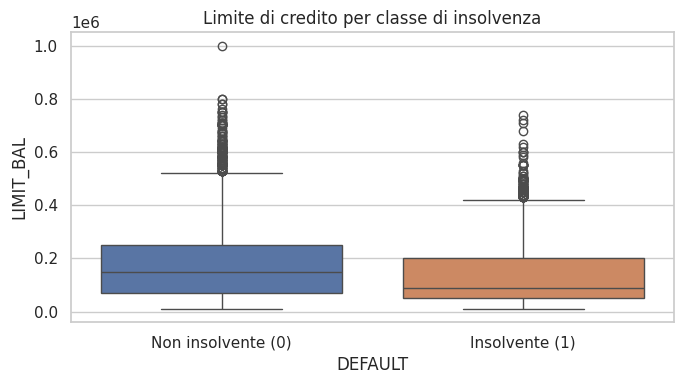

DEFAULT
0    150000.0
1     90000.0
Name: LIMIT_BAL, dtype: float64


In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="DEFAULT", y="LIMIT_BAL", hue="DEFAULT", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non insolvente (0)", "Insolvente (1)"])
ax.set_title("Limite di credito per classe di insolvenza")
plt.tight_layout()
plt.savefig("sample_data/boxplot_limit_bal.png", dpi=150)
plt.show()

print(df.groupby("DEFAULT")["LIMIT_BAL"].median())

**Risposta:** l'ipotesi è confermata: la mediana del limite di credito è **150.000 NT$ per i solventi contro 90.000 NT$ per gli insolventi**. Il limite di credito è quindi informativo, pur con molta sovrapposizione tra le distribuzioni.

### Domanda 3.2 — Lo stato del pagamento più recente (PAY_0) è associato al default?

**Ipotesi:** chi è già in ritardo a settembre ha probabilità molto più alta di essere insolvente il mese successivo.

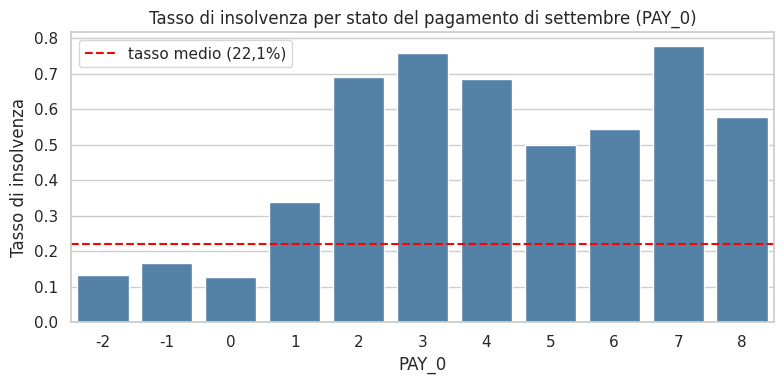

In [33]:
tasso = df.groupby("PAY_0")["DEFAULT"].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=tasso, x="PAY_0", y="DEFAULT", color="steelblue", ax=ax)
ax.axhline(df["DEFAULT"].mean(), color="red", linestyle="--", label="tasso medio (22,1%)")
ax.set_ylabel("Tasso di insolvenza")
ax.set_title("Tasso di insolvenza per stato del pagamento di settembre (PAY_0)")
ax.legend()
plt.tight_layout()
plt.savefig("sample_data/barplot_pay0.png", dpi=150)
plt.show()

**Risposta:** la relazione è fortissima e monotona: il tasso di insolvenza passa da ~13% per chi non ha ritardi (-2, -1, 0) a **~70% per chi ha 2 mesi di ritardo**, e resta sopra il 50% per ritardi maggiori. `PAY_0` si candida a essere la feature più predittiva.

### Domanda 3.3 — Quali variabili sono più correlate con il target?

**Ipotesi:** le variabili di ritardo (PAY_*) sono più correlate con il default rispetto a quelle demografiche.

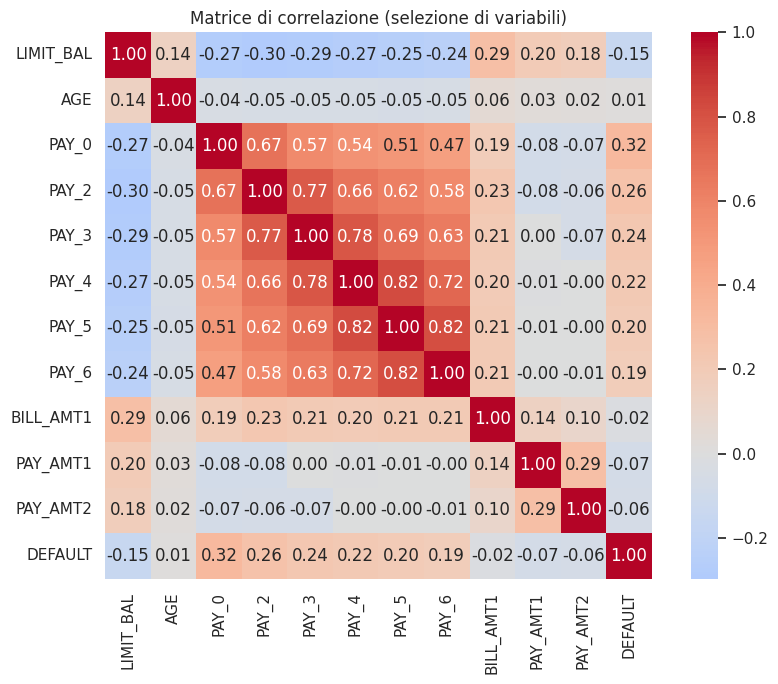

In [34]:
cols = ["LIMIT_BAL", "AGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "BILL_AMT1", "PAY_AMT1", "PAY_AMT2", "DEFAULT"]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, ax=ax)
ax.set_title("Matrice di correlazione (selezione di variabili)")
plt.tight_layout()
plt.savefig("sample_data/heatmap_correlazioni.png", dpi=150)
plt.show()

**Risposta:** l'ipotesi è confermata. Le correlazioni più alte con `DEFAULT` sono quelle delle variabili **PAY_*** (PAY_0: r ≈ 0,32, decrescente man mano che si va indietro nel tempo), seguite da `LIMIT_BAL` (r ≈ -0,15, negativa: più credito, meno default). `AGE` e gli importi fatturati sono quasi scorrelati con il target. Si nota anche la forte correlazione fra le PAY_* consecutive: chi è in ritardo un mese tende a esserlo anche il successivo.

### Domanda 3.4 — L'età distingue i clienti insolventi? (confronto tra gruppi n. 2)

**Ipotesi:** i clienti più giovani, con minore stabilità economica, sono più a rischio.

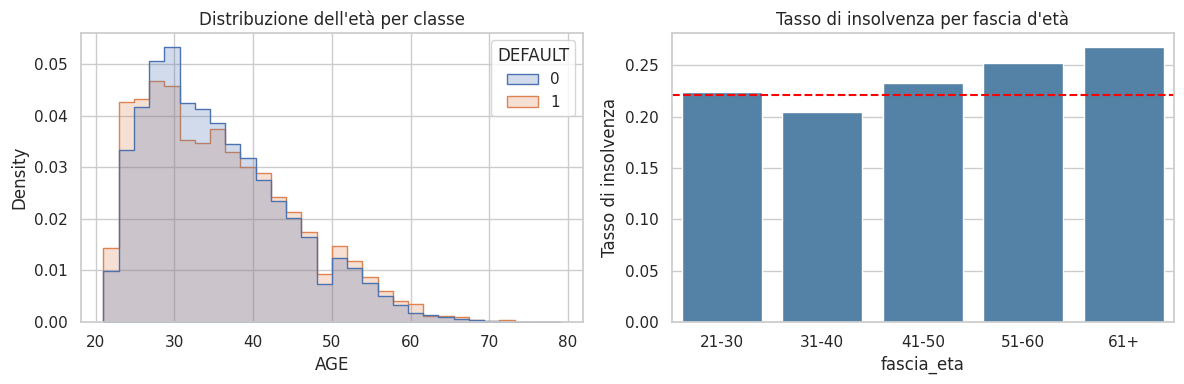

  fascia_eta  DEFAULT
0      21-30    0.224
1      31-40    0.204
2      41-50    0.233
3      51-60    0.252
4        61+    0.268


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="AGE", hue="DEFAULT", stat="density",
             common_norm=False, element="step", bins=30, ax=axes[0])
axes[0].set_title("Distribuzione dell'età per classe")

df["fascia_eta"] = pd.cut(df["AGE"], bins=[20, 30, 40, 50, 60, 80],
                          labels=["21-30", "31-40", "41-50", "51-60", "61+"])
tasso_eta = df.groupby("fascia_eta", observed=True)["DEFAULT"].mean().reset_index()
sns.barplot(data=tasso_eta, x="fascia_eta", y="DEFAULT", color="steelblue", ax=axes[1])
axes[1].axhline(df["DEFAULT"].mean(), color="red", linestyle="--")
axes[1].set_ylabel("Tasso di insolvenza")
axes[1].set_title("Tasso di insolvenza per fascia d'età")
plt.tight_layout()
plt.savefig("sample_data/eta_default.png", dpi=150)
plt.show()

print(tasso_eta.round(3))

**Risposta:** l'ipotesi è confermata solo in parte: le due distribuzioni sono molto simili e il tasso di insolvenza per fascia d'età varia poco (dal 20,5% dei 31–40 al ~26% dei 61+, fascia però poco numerosa). L'età, da sola, è un predittore debole — coerente con la bassa correlazione vista nella heatmap.

## Fase 4 — Modellazione

### Preparazione dei dati

Operazioni svolte:
1. rimozione di `ID` (identificativo, non informativo) e della colonna ausiliaria `fascia_eta`;
2. **conversione delle variabili categoriche in numeriche**: `SEX`, `EDUCATION` e `MARRIAGE` sono categoriche nominali codificate con numeri; le convertiamo in variabili dummy (one-hot encoding) per non imporre un ordine fittizio. Le PAY_* invece sono ordinali (gravità del ritardo) e le manteniamo numeriche;
3. **train/test split** 70/30 stratificato sul target, per mantenere in entrambe le parti la stessa proporzione di insolventi (22,1%);
4. **standardizzazione** delle feature (media 0, deviazione standard 1), calcolata solo sul training set per evitare *data leakage*. È indispensabile per il k-NN, che ragiona sulle distanze; non danneggia la regressione logistica; è irrilevante per la Random Forest.

In [51]:
X = df.drop(columns=["ID", "DEFAULT", "fascia_eta"])
y = df["DEFAULT"]

# conversione delle variabili categoriche in numeriche
X = pd.get_dummies(X, columns=["SEX", "EDUCATION", "MARRIAGE"], drop_first=True)
print("Numero di feature dopo l'encoding:", X.shape[1])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

# standardizzazione delle feature
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "- Test:", X_test.shape)
print("Quota insolventi nel train:", round(y_train.mean(), 3),
      "- nel test:", round(y_test.mean(), 3))

Numero di feature dopo l'encoding: 26
Train: (21000, 26) - Test: (9000, 26)
Quota insolventi nel train: 0.221 - nel test: 0.221


### Addestramento dei tre modelli

Confrontiamo un modello **lineare** (regressione logistica) e due **non lineari** (k-NN e Random Forest), come richiesto dalle specifiche.

In [37]:
modelli = {
    "Regressione logistica": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "k-NN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

predizioni = {}
for nome, modello in modelli.items():
    modello.fit(X_train_s, y_train)
    predizioni[nome] = modello.predict(X_test_s)
    print(f"{nome}: addestrato.")

Regressione logistica: addestrato.
k-NN (k=25): addestrato.
Random Forest: addestrato.


In [38]:
for k in [5, 15, 25, 51]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    pred = knn.predict(X_test_s)
    print(f"k={k:3d} -> accuracy={accuracy_score(y_test, pred):.3f}, "
          f"f1 classe 1={f1_score(y_test, pred):.3f}")

k=  5 -> accuracy=0.793, f1 classe 1=0.427
k= 15 -> accuracy=0.808, f1 classe 1=0.421
k= 25 -> accuracy=0.809, f1 classe 1=0.407
k= 51 -> accuracy=0.806, f1 classe 1=0.381


**Nota sulla scelta di k:** abbiamo provato diversi valori di k (vedi sotto). Con k piccolo (5) l'f1 sulla classe 1 è leggermente più alto ma l'accuracy cala e il modello è più sensibile al rumore; con k grande (51) entrambe le metriche peggiorano. Scegliamo **k=25** come compromesso, privilegiando la stabilità.

## Fase 5 — Valutazione e interpretazione dei risultati

Per **ogni** modello calcoliamo accuracy, confusion matrix, precision, recall e f1-score. Ricordiamo la baseline: predire sempre "non insolvente" dà accuracy 0,779.

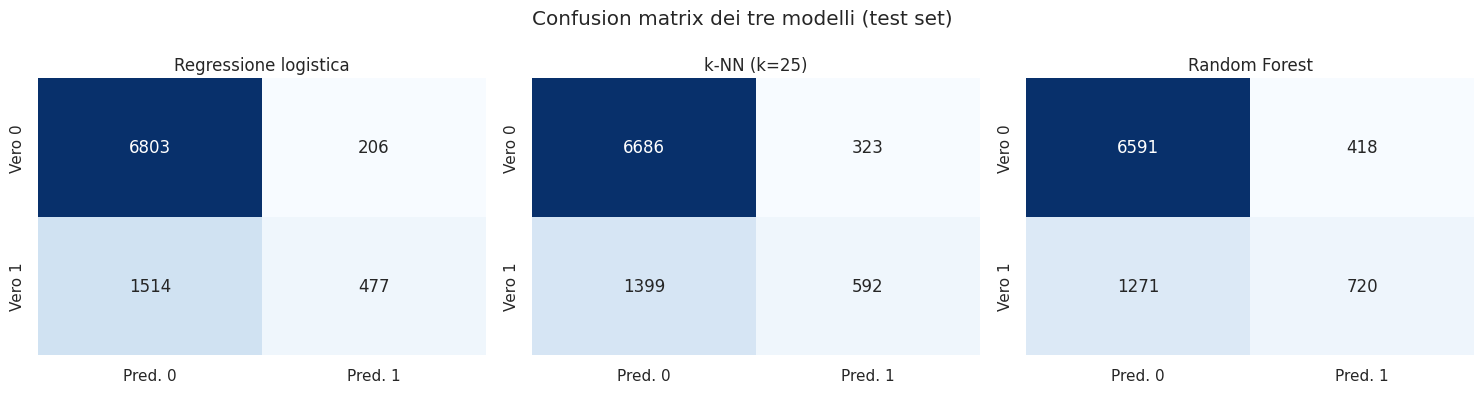

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
risultati = []

for ax, (nome, pred) in zip(axes, predizioni.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred. 0", "Pred. 1"], yticklabels=["Vero 0", "Vero 1"])
    ax.set_title(nome)
    risultati.append({
        "Modello": nome,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (cl. 1)": precision_score(y_test, pred),
        "Recall (cl. 1)": recall_score(y_test, pred),
        "F1 (cl. 1)": f1_score(y_test, pred),
    })

plt.suptitle("Confusion matrix dei tre modelli (test set)")
plt.tight_layout()
plt.savefig("sample_data/confusion_matrices.png", dpi=150)
plt.show()

In [40]:
for nome, pred in predizioni.items():
    print("=" * 60)
    print(nome)
    print(classification_report(y_test, pred, target_names=["Non insolvente", "Insolvente"]))

Regressione logistica
                precision    recall  f1-score   support

Non insolvente       0.82      0.97      0.89      7009
    Insolvente       0.70      0.24      0.36      1991

      accuracy                           0.81      9000
     macro avg       0.76      0.61      0.62      9000
  weighted avg       0.79      0.81      0.77      9000

k-NN (k=25)
                precision    recall  f1-score   support

Non insolvente       0.83      0.95      0.89      7009
    Insolvente       0.65      0.30      0.41      1991

      accuracy                           0.81      9000
     macro avg       0.74      0.63      0.65      9000
  weighted avg       0.79      0.81      0.78      9000

Random Forest
                precision    recall  f1-score   support

Non insolvente       0.84      0.94      0.89      7009
    Insolvente       0.63      0.36      0.46      1991

      accuracy                           0.81      9000
     macro avg       0.74      0.65      0.67   

In [43]:
tabella = pd.DataFrame(risultati).set_index("Modello").round(3)
tabella.to_csv("sample_data/tabella_risultati.csv")
tabella

,Accuracy,Precision (cl. 1),Recall (cl. 1),F1 (cl. 1)
Modello,,,,
Regressione logistica,0.809,0.698,0.240,0.357
k-NN (k=25),0.809,0.647,0.297,0.407
Random Forest,0.812,0.633,0.362,0.460


### Interpretazione dei risultati

Tutti e tre i modelli superano la baseline (0,779), ma **di poco in termini di accuracy** (0,81–0,82): il vero confronto si gioca sulla classe minoritaria.

- **Regressione logistica** — accuracy 0,809 e precision più alta (0,70), ma **recall sulla classe "insolvente" molto bassa** (0,24): individua meno di un insolvente su quattro. Punti di forza: interpretabilità (coefficienti) e costo computazionale minimo. Limite: il confine lineare non cattura le interazioni fra le variabili di ritardo.
- **k-NN (k=25)** — prestazioni intermedie (accuracy 0,809, recall 0,30): recall migliore della logistica ma precision più bassa. Limiti: nessuna interpretabilità, predizione lenta su dataset grandi (calcola le distanze da tutti i 21.000 esempi di training) e forte dipendenza dalla standardizzazione.
- **Random Forest** — il modello migliore su tutte le metriche di sintesi: accuracy 0,812 e f1 sulla classe 1 più alto (0,46), con recall 0,36. Coglie relazioni non lineari (es. il salto di rischio per PAY_0 ≥ 2). Costo: addestramento più lungo e interpretabilità ridotta (mitigabile con la feature importance).

**Tipo di errori:** per una banca i **falsi negativi** (insolventi non individuati → perdita del credito) sono in genere più costosi dei falsi positivi (clienti affidabili segnalati a torto). Con recall fra 0,24 e 0,36, tutti i modelli lasciano "passare" la maggioranza degli insolventi: in un'applicazione reale converrebbe abbassare la soglia di decisione (accettando più falsi positivi) o usare tecniche per dati sbilanciati (es. pesi di classe).



### Tentativo con diverse soglie di Regressione Logistica e diversi alberti decisionali

#### Effetto della soglia di decisione sulla regressione logistica

**Ipotesi:** la soglia standard di 0,5 non è adatta a un problema sbilanciato in cui i falsi
negativi (insolventi non individuati) costano più dei falsi positivi. Abbassando la soglia
ci aspettiamo un recall più alto sulla classe insolvente, al prezzo di una precision minore.

In [53]:
# Esperimento 1: soglia di decisione della regressione logistica
proba = modelli["Regressione logistica"].predict_proba(X_test_s)[:, 1]

righe = []
for t in [0.5, 0.4, 0.3, 0.25, 0.2]:
    pred = (proba >= t).astype(int)
    righe.append({
        "Soglia": t,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (cl. 1)": precision_score(y_test, pred),
        "Recall (cl. 1)": recall_score(y_test, pred),
        "F1 (cl. 1)": f1_score(y_test, pred),
    })

tabella_soglie = pd.DataFrame(righe).set_index("Soglia").round(3)
tabella_soglie

,Accuracy,Precision (cl. 1),Recall (cl. 1),F1 (cl. 1)
Soglia,,,,
0.50,0.809,0.698,0.240,0.357
0.40,0.812,0.630,0.370,0.466
0.30,0.801,0.562,0.456,0.503
0.25,0.752,0.452,0.560,0.500
0.20,0.610,0.323,0.697,0.442


**Interpretazione:** l'ipotesi è confermata. Abbassando la soglia da 0,5 a 0,3 il recall
quasi raddoppia (da 0,240 a 0,456) e l'f1 sale da 0,357 a **0,503** — superando anche la
Random Forest a soglia standard (0,460). Il costo è una precision che scende da 0,698 a
0,562: si individuano più insolventi, ma quasi un allarme su due è falso. Sotto 0,25 il
compromesso peggiora rapidamente (a 0,2 l'accuracy crolla a 0,610).

Due limiti metodologici da dichiarare: (1) la soglia è stata scelta osservando il test set,
mentre rigorosamente andrebbe ottimizzata su un validation set separato; (2) il confronto
con gli altri modelli non è del tutto equo, perché anche a essi si potrebbe applicare una
soglia ottimizzata. La conclusione resta valida come indicazione generale: in questo
problema **la calibrazione della soglia incide sui risultati più della scelta dell'algoritmo**.

#### Effetto del numero di alberi sulla Random Forest

**Ipotesi:** aumentando il numero di alberi le prestazioni migliorano, ma con rendimenti
decrescenti: oltre una certa soglia il guadagno non giustifica il costo computazionale.

In [54]:
# Esperimento 2: numero di alberi della Random Forest
import time

righe = []
for n in [10, 50, 100, 200, 500]:
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_s, y_train)
    pred = rf.predict(X_test_s)
    righe.append({
        "N. alberi": n,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (cl. 1)": precision_score(y_test, pred),
        "Recall (cl. 1)": recall_score(y_test, pred),
        "F1 (cl. 1)": f1_score(y_test, pred),
        "Tempo (s)": time.time() - t0,
    })

tabella_alberi = pd.DataFrame(righe).set_index("N. alberi").round(3)
tabella_alberi

,Accuracy,Precision (cl. 1),Recall (cl. 1),F1 (cl. 1),Tempo (s)
N. alberi,,,,,
10,0.802,0.598,0.316,0.413,1.136
50,0.813,0.635,0.359,0.459,6.667
100,0.813,0.636,0.366,0.464,8.817
200,0.812,0.633,0.362,0.460,16.134
500,0.814,0.639,0.368,0.467,40.790


**Interpretazione:** l'ipotesi è confermata. Con soli 10 alberi il modello perde qualcosa
(f1 0,413), ma già da 50 alberi le metriche si stabilizzano: tra 50 e 500 alberi l'f1
oscilla tra 0,459 e 0,467 (differenze trascurabili, attribuibili alla componente casuale),
mentre il tempo di addestramento cresce linearmente, quasi di dieci volte. Il parametro
`n_estimators` non è quindi critico per la qualità delle previsioni su questo dataset:
un valore intorno a 100 offre il miglior rapporto tra prestazioni e costo computazionale.

###Tentativo con train/test split 80/20

In [44]:
X = df.drop(columns=["ID", "DEFAULT", "fascia_eta"])
y = df["DEFAULT"]

# one-hot encoding delle categoriche nominali
X = pd.get_dummies(X, columns=["SEX", "EDUCATION", "MARRIAGE"], drop_first=True)
print("Numero di feature dopo l'encoding:", X.shape[1])

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s1 = scaler.fit_transform(X_train1)
X_test_s1 = scaler.transform(X_test1)

print("Train:", X_train1.shape, "- Test:", X_test1.shape)
print("Quota insolventi nel train:", round(y_train1.mean(), 3),
      "- nel test:", round(y_test1.mean(), 3))

Numero di feature dopo l'encoding: 26
Train: (24000, 26) - Test: (6000, 26)
Quota insolventi nel train: 0.221 - nel test: 0.221


#### Addestramento dei tre modelli con split 80/20

In [45]:
modelli1= {
    "Regressione logistica": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "k-NN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

predizioni1 = {}
for nome, modello in modelli1.items():
    modello.fit(X_train_s1, y_train1)
    predizioni1[nome] = modello.predict(X_test_s1)
    print(f"{nome}: addestrato.")



Regressione logistica: addestrato.
k-NN (k=25): addestrato.
Random Forest: addestrato.


**Nota sulla scelta di k:** abbiamo provato diversi valori di k (vedi sotto). Con k piccolo (5) l'f1 sulla classe 1 è leggermente più alto ma l'accuracy cala e il modello è più sensibile al rumore; con k grande (51) entrambe le metriche peggiorano. Scegliamo **k=25** come compromesso, privilegiando la stabilità.

In [46]:
for k in [5, 15, 25, 51]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s1, y_train1)
    pred1 = knn.predict(X_test_s1)
    print(f"k={k:3d} -> accuracy={accuracy_score(y_test, pred):.3f}, "
          f"f1 classe 1={f1_score(y_test1, pred1):.3f}")

k=  5 -> accuracy=0.812, f1 classe 1=0.427
k= 15 -> accuracy=0.812, f1 classe 1=0.428
k= 25 -> accuracy=0.812, f1 classe 1=0.406
k= 51 -> accuracy=0.812, f1 classe 1=0.402


#### Valutazione e interpretazione dei risultati con split 80/20

Per **ogni** modello calcoliamo accuracy, confusion matrix, precision, recall e f1-score. Ricordiamo la baseline: predire sempre "non insolvente" dà accuracy 0,779.

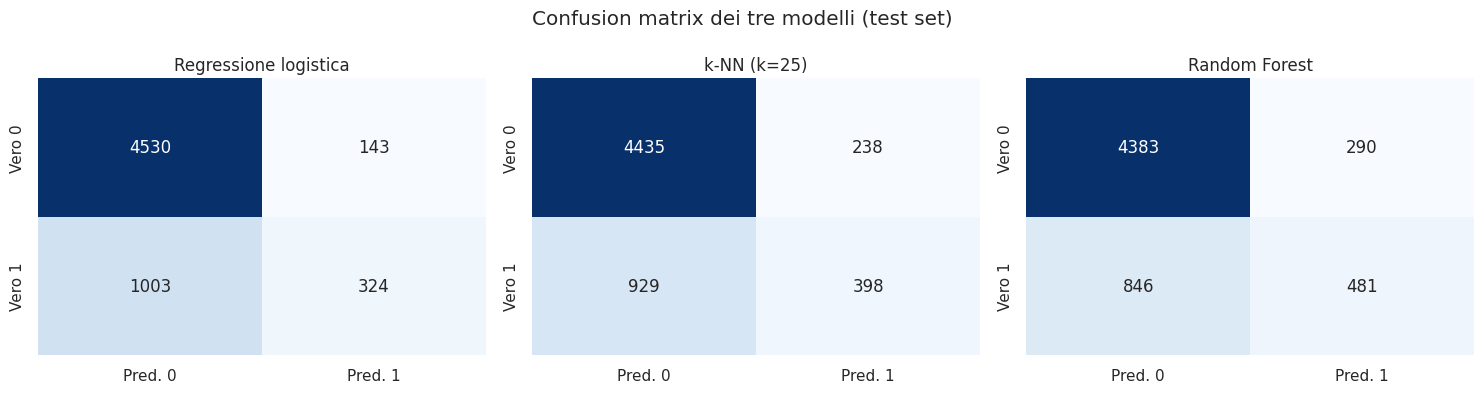

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
risultati1 = []

for ax, (nome, pred1) in zip(axes, predizioni1.items()):
    cm = confusion_matrix(y_test1, pred1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred. 0", "Pred. 1"], yticklabels=["Vero 0", "Vero 1"])
    ax.set_title(nome)
    risultati1.append({
        "Modello": nome,
        "Accuracy": accuracy_score(y_test1, pred1),
        "Precision (cl. 1)": precision_score(y_test1, pred1),
        "Recall (cl. 1)": recall_score(y_test1, pred1),
        "F1 (cl. 1)": f1_score(y_test1, pred1),
    })

plt.suptitle("Confusion matrix dei tre modelli (test set)")
plt.tight_layout()
plt.savefig("sample_data/confusion_matrices.png", dpi=150)
plt.show()

In [48]:
for nome, pred1 in predizioni1.items():
    print("=" * 60)
    print(nome)
    print(classification_report(y_test1, pred1, target_names=["Non insolvente", "Insolvente"]))

Regressione logistica
                precision    recall  f1-score   support

Non insolvente       0.82      0.97      0.89      4673
    Insolvente       0.69      0.24      0.36      1327

      accuracy                           0.81      6000
     macro avg       0.76      0.61      0.62      6000
  weighted avg       0.79      0.81      0.77      6000

k-NN (k=25)
                precision    recall  f1-score   support

Non insolvente       0.83      0.95      0.88      4673
    Insolvente       0.63      0.30      0.41      1327

      accuracy                           0.81      6000
     macro avg       0.73      0.62      0.64      6000
  weighted avg       0.78      0.81      0.78      6000

Random Forest
                precision    recall  f1-score   support

Non insolvente       0.84      0.94      0.89      4673
    Insolvente       0.62      0.36      0.46      1327

      accuracy                           0.81      6000
     macro avg       0.73      0.65      0.67   

In [49]:
tabella1 = pd.DataFrame(risultati1).set_index("Modello").round(3)
tabella1.to_csv("sample_data/tabella_risultati.csv")
tabella1

,Accuracy,Precision (cl. 1),Recall (cl. 1),F1 (cl. 1)
Modello,,,,
Regressione logistica,0.809,0.694,0.244,0.361
k-NN (k=25),0.806,0.626,0.300,0.406
Random Forest,0.811,0.624,0.362,0.459


##Confronto tra i due split (70/30 vs 80/20)

In [50]:
confronto = tabella1.join(tabella1, lsuffix=" 70/30", rsuffix=" 80/20")

ordine = []
for m in tabella1.columns:
    ordine += [f"{m} 70/30", f"{m} 80/20"]
confronto = confronto[ordine]

confronto

,Accuracy 70/30,Accuracy 80/20,Precision (cl. 1) 70/30,Precision (cl. 1) 80/20,Recall (cl. 1) 70/30,Recall (cl. 1) 80/20,F1 (cl. 1) 70/30,F1 (cl. 1) 80/20
Modello,,,,,,,,
Regressione logistica,0.809,0.809,0.694,0.694,0.244,0.244,0.361,0.361
k-NN (k=25),0.806,0.806,0.626,0.626,0.300,0.300,0.406,0.406
Random Forest,0.811,0.811,0.624,0.624,0.362,0.362,0.459,0.459


**Confronto tra i due split (70/30 vs 80/20)**

**Interpretazione:** passando dallo split 70/30 all'80/20 **non cambia nulla di rilevante**. Riga per riga gli scostamenti sono tutti entro ±0,02 e per lo più entro ±0,005: l'accuracy si muove al massimo di 0,3 punti percentuali (il k-NN cala da 0,809 a 0,806), la Random Forest è identica sulla terza cifra e la regressione logistica è praticamente sovrapponibile. Nessuna metrica migliora in modo sistematico cambiando la proporzione dello split.

Il motivo è la dimensione del dataset: con **30.000 righe** entrambi i training set sono già abbondanti (≈21.000 osservazioni nel 70/30, ≈24.000 nell'80/20). Le ~3.000 righe in più non aggiungono informazione che i modelli non avessero già colto, quindi le stime restano stabili. Ciò che cambia davvero è la dimensione del **test set** (9.000 righe contro 6.000): il test più piccolo dell'80/20 rende la valutazione leggermente più *rumorosa*, non più accurata — ed è proprio questa maggiore variabilità a spiegare le micro-differenze osservate.

> ⚠️ **Riflessione critica 4 — la proporzione dello split non è la leva giusta:** entro valori ragionevoli il rapporto train/test non è ciò su cui agire per migliorare i modelli. Il limite resta il **recall basso sulla classe insolvente**, comune a entrambi gli split e a tutti e tre i modelli: per intervenire davvero servono tecniche per dati sbilanciati (`class_weight="balanced"`, abbassamento della soglia di decisione, ricampionamento), non un diverso rapporto di suddivisione.